In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns

In [60]:
all_features = pd.read_parquet("../all_features.parquet")
all_features.head()

import os
os.chdir("../rebecca")

In [61]:
all_features.columns

Index(['customer_id', 'customer_type', 'label', 'cash_value_ratio',
       'emt_velocity_monthly_mean', 'income_transaction_gap_score',
       'is_retired', 'is_unemployed', 'occupation_sector_id',
       'spending_income_ratio', 'rapid_outflow_ratio_24h', 'mean_debit',
       'median_debit', 'std_debit', 'iqr_debit', 'mad_debit', 'skew_debit',
       'kurt_debit', 'mean_credit', 'median_credit', 'std_credit',
       'iqr_credit', 'mad_credit', 'skew_credit', 'kurt_credit',
       'mean_velocity', 'median_velocity', 'std_velocity', 'iqr_velocity',
       'mad_velocity', 'skew_velocity', 'late_night_txn_count',
       'late_night_ratio', 'weekend_txn_count', 'activity_span_days',
       'unique_merchant_categories', 'msb_tx_n', 'msb_active_days',
       'msb_channels_n', 'id_msb_in_total', 'id_msb_out_total',
       'msb_tx_per_day', 'msb_pass_through_ratio', 'msb_net_retention_ratio',
       'struct_total_near_n', 'struct_days_with_near',
       'struct_max_near_in_day', 'struct_total_

In [24]:
all_features["customer_type_ind"] = np.where(all_features["customer_type"] == "IND", 0, 1)

# kurt_debit, kurt_credit all NA
all_features.drop(["customer_type", "kurt_debit", "kurt_credit"], axis=1, inplace=True)

## Correlation Matrix

In [25]:
labelled = all_features[all_features["label"].notnull()]
labelled.drop(["customer_id"], axis=1, inplace=True)

unlabelled = all_features[all_features["label"].isnull()]
unlabelled.drop(["customer_id"], axis=1, inplace=True)

/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_43397/2908375937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled.drop(["customer_id"], axis=1, inplace=True)
/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_43397/2908375937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabelled.drop(["customer_id"], axis=1, inplace=True)


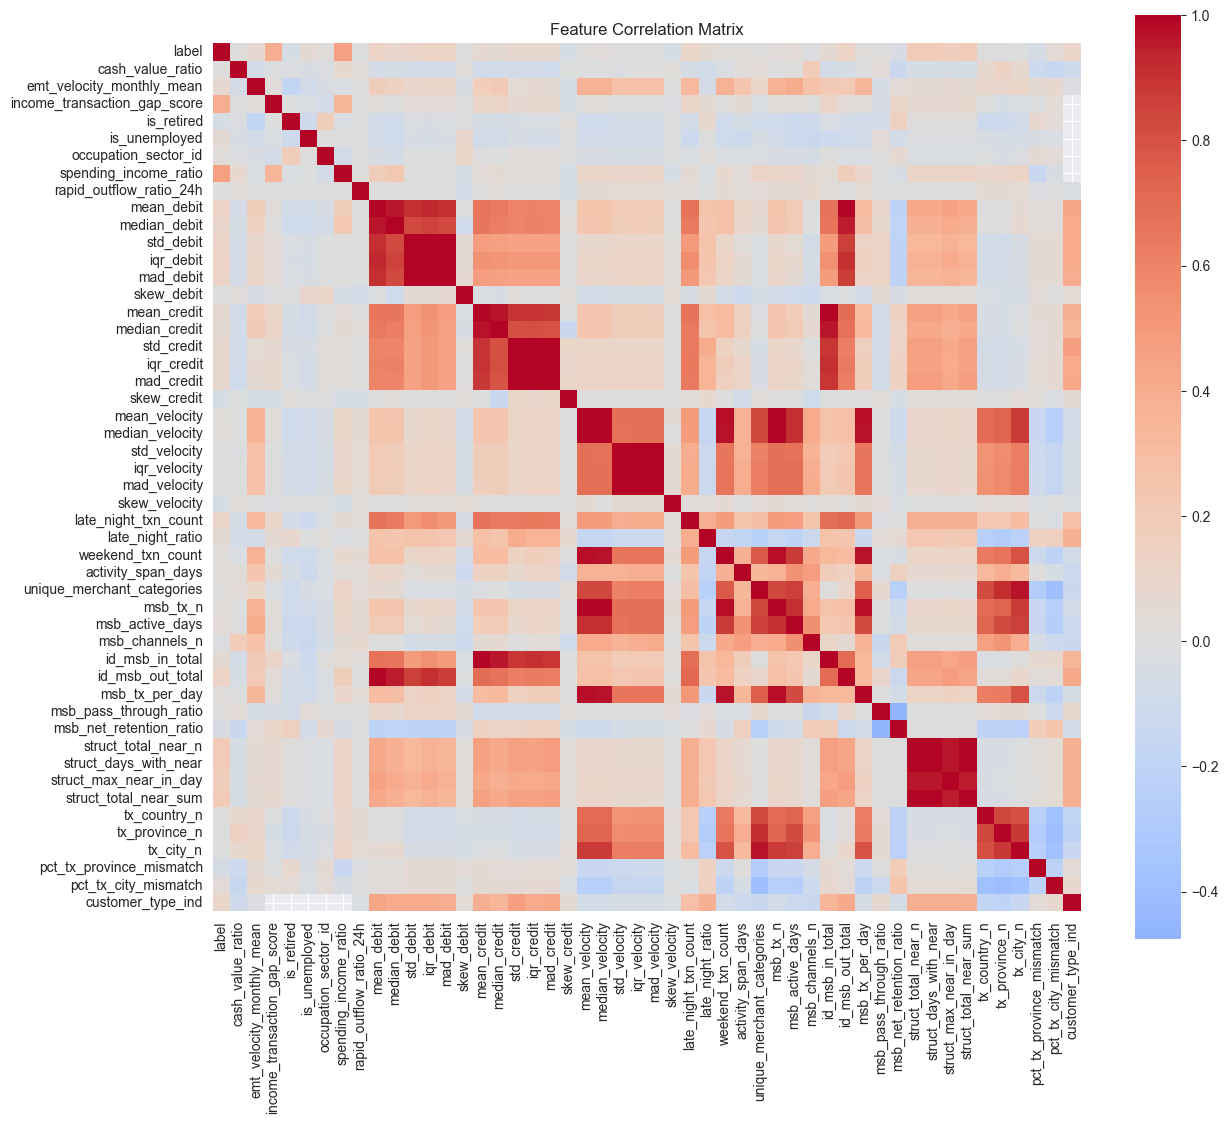

In [26]:
corr = labelled.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [27]:
# drop correlated features above threshold 0.9
corr_matrix = labelled.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9

to_drop = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

labelled_df = labelled.drop(columns=to_drop)
unlabelled_df = unlabelled.drop(columns=to_drop)

print(f"Dropped {len(to_drop)} features")

Dropped 22 features


## Impute missing data

In [28]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(max_iter=20, random_state=42)

labelled_imp = imp.fit_transform(labelled_df)
unlabelled_imp = imp.transform(unlabelled_df)

labelled_imp = pd.DataFrame(labelled_imp, columns=labelled_df.columns, index=labelled_df.index)
unlabelled_imp = pd.DataFrame(unlabelled_imp, columns=unlabelled_df.columns, index=unlabelled_df.index)
columns = unlabelled_imp.columns

labelled_imp.head()

/Users/rebeccalee/Library/Python/3.11/lib/python/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,rapid_outflow_ratio_24h,mean_debit,...,activity_span_days,unique_merchant_categories,msb_channels_n,msb_pass_through_ratio,msb_net_retention_ratio,struct_total_near_n,tx_country_n,pct_tx_province_mismatch,pct_tx_city_mismatch,customer_type_ind
2,0.0,0.037841,0.0,1.460746,1.0,0.0,18.0,0.234281,0.0,1229.440000,...,91.0,12.0,3.0,0.505042,0.328867,0.0,1.0,0.75,0.975,0.0
103,0.0,0.000000,0.0,0.565197,0.0,0.0,18.0,0.000000,0.0,1192.126667,...,90.0,0.0,2.0,0.597853,0.251680,0.0,0.0,1.00,1.000,0.0
164,0.0,0.000000,0.0,0.036114,1.0,0.0,18.0,0.000000,0.0,-3836.138713,...,1.0,0.0,1.0,0.000000,1.000000,0.0,0.0,1.00,1.000,0.0
274,0.0,0.000000,1.0,1.215037,0.0,1.0,17.0,0.000000,0.0,-15315.736194,...,1.0,0.0,1.0,0.000000,1.000000,0.0,0.0,1.00,1.000,0.0
280,0.0,0.000000,2.0,0.273064,1.0,0.0,18.0,0.000000,0.0,949.250000,...,89.0,0.0,2.0,0.488426,0.343701,0.0,0.0,1.00,1.000,0.0


# Part 1: PCA on labelled data

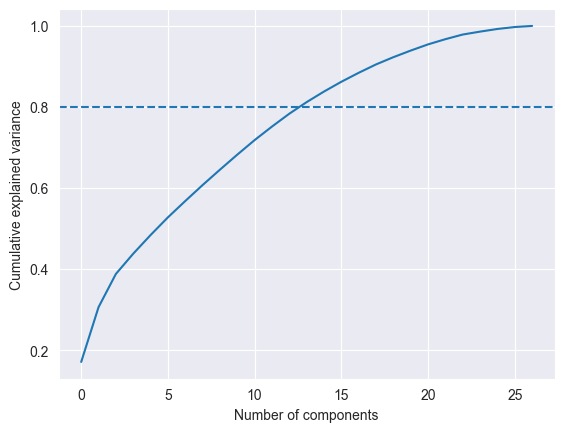

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

labels = labelled_imp['label']

# drop ID column
X = labelled_imp.drop(columns=['label'])

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# visualize
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(y=0.8, linestyle='--')
plt.show()

# re-fit pca with opt # components
pca_opt = PCA(n_components=12)
X_pca = pca_opt.fit_transform(X_scaled)

In [30]:
# variation per principal component by feature
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_opt.n_components_)],
    index=X.columns)

loadings.style.background_gradient(
    cmap="coolwarm",
    subset=[f'PC{i+1}' for i in range(pca_opt.n_components_)])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
cash_value_ratio,0.008329,-0.090070,-0.098503,-0.163178,-0.323667,0.212821,-0.403083,0.548031,0.156009,-0.148606,-0.136959,0.096885
emt_velocity_monthly_mean,0.187005,-0.008183,0.178707,-0.119782,0.492019,0.142106,0.080583,0.030176,-0.129665,-0.163992,0.020574,0.281237
income_transaction_gap_score,0.078406,0.120317,0.087360,-0.295699,-0.358059,0.069268,0.509513,0.063654,-0.131846,0.287939,-0.036769,0.175905
is_retired,-0.056707,0.086452,0.090234,0.329055,-0.477720,-0.179721,-0.136815,-0.201082,-0.013785,-0.186900,0.302494,-0.028815
is_unemployed,-0.223132,-0.308282,0.057157,0.011326,0.058664,-0.090544,0.182008,0.038103,-0.017434,0.251418,-0.220730,-0.075336
occupation_sector_id,-0.066195,-0.041475,0.084697,0.365386,-0.177211,-0.238944,0.025608,-0.004747,-0.403746,-0.314321,-0.172918,0.294745
spending_income_ratio,0.163578,0.165646,-0.132629,-0.325881,-0.359489,0.051596,0.255665,-0.024366,-0.063558,0.015927,0.066135,0.157799
rapid_outflow_ratio_24h,0.029079,-0.026999,0.030275,-0.083806,-0.072038,0.025202,-0.492148,-0.236003,-0.389342,0.395911,-0.305162,0.410262
mean_debit,0.263224,0.321958,-0.200153,-0.028054,0.026008,0.055006,-0.094640,-0.042581,-0.033722,-0.185579,0.156676,0.093166
skew_debit,-0.045194,0.020944,-0.071110,0.218215,0.059059,-0.153762,0.300667,0.562163,-0.257376,-0.177329,-0.228890,0.065490


In [31]:
# most important features for each prinicpal component
loadings['PC1'].abs().sort_values(ascending=False)

mean_velocity                   0.380725
late_night_txn_count            0.354034
std_velocity                    0.334722
unique_merchant_categories      0.320070
tx_country_n                    0.289734
mean_credit                     0.268705
mean_debit                      0.263224
msb_channels_n                  0.241995
activity_span_days              0.229435
is_unemployed                   0.223132
emt_velocity_monthly_mean       0.187005
struct_total_near_n             0.163623
spending_income_ratio           0.163578
pct_tx_city_mismatch            0.100323
income_transaction_gap_score    0.078406
customer_type_ind               0.074059
occupation_sector_id            0.066195
pct_tx_province_mismatch        0.059617
is_retired                      0.056707
msb_pass_through_ratio          0.048244
skew_debit                      0.045194
msb_net_retention_ratio         0.041515
rapid_outflow_ratio_24h         0.029079
skew_velocity                   0.019212
skew_credit     

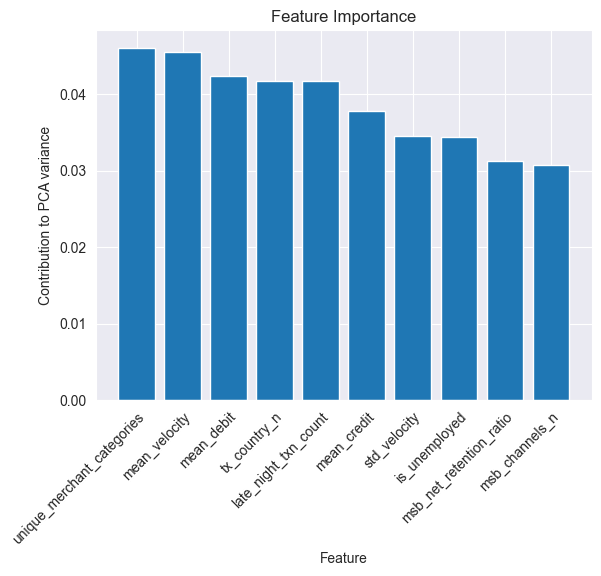

In [66]:
# variance explained
variance = pca_opt.explained_variance_ratio_

# weighted importance
importance = (loadings**2).dot(variance)

importance = importance.sort_values(ascending=False)

importance_df = importance.reset_index()
importance_df.columns = ["feature", "importance"]

plt.bar(importance_df["feature"][:10], importance_df["importance"][:10])
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Contribution to PCA variance")
# plt.savefig("PCA_importance.png", bbox_inches="tight")
plt.show()

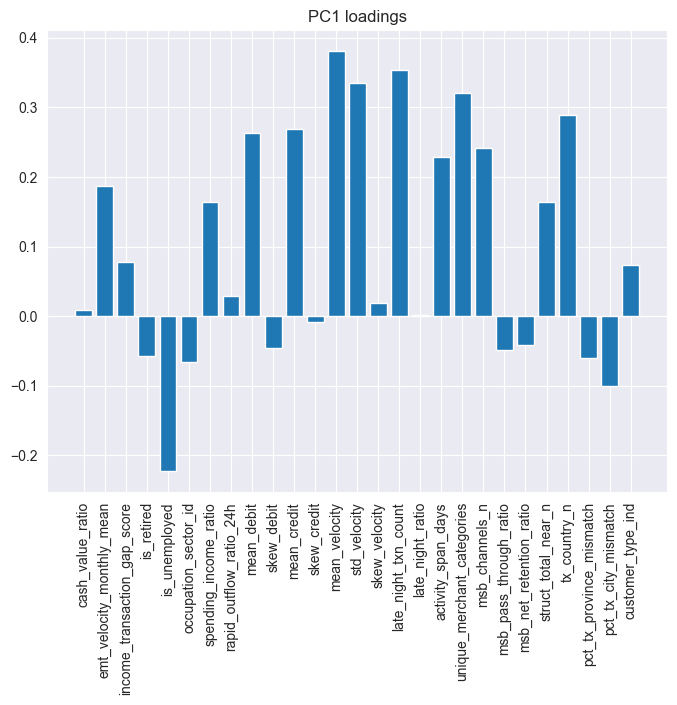

In [32]:
# biplot arrows
plt.figure(figsize=(8,6))
plt.bar(loadings.index, loadings['PC1'])
plt.xticks(rotation=90)
plt.title("PC1 loadings")
plt.show()

In [33]:
# explained variance per each component
explained = pd.DataFrame({
    'PC': range(1, len(pca_opt.explained_variance_ratio_)+1),
    'variance_explained': pca_opt.explained_variance_ratio_})

explained

,PC,variance_explained
0,1,0.171018
1,2,0.135086
2,3,0.081992
3,4,0.049949
4,5,0.045972
5,6,0.043669
6,7,0.040312
7,8,0.039372
8,9,0.037936
9,10,0.037119


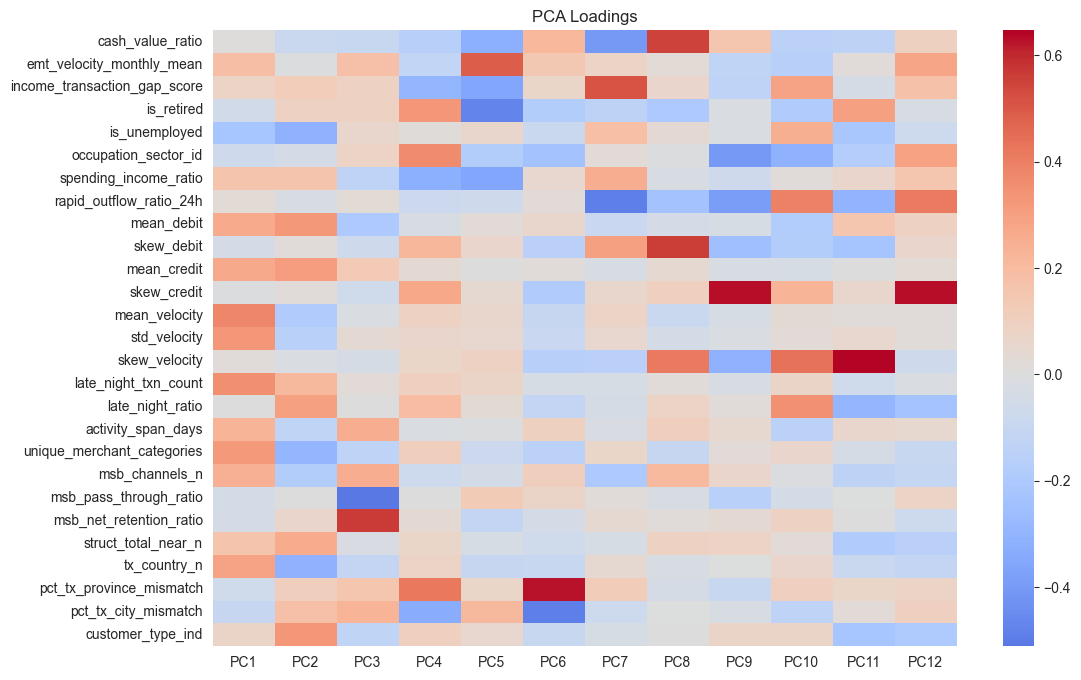

In [34]:
# importance heatmap
plt.figure(figsize=(12,8))
sns.heatmap(loadings, cmap='coolwarm', center=0)
plt.title("PCA Loadings")
plt.show()

## Part 1.1: Cluster PCA data

In [35]:
X_pca_data = X.copy()

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X_pca_data['cluster'] = clusters

tmp = pd.DataFrame({"label": labels, "cluster": clusters}, index=X_pca_data.index)
labelled_tmp = tmp[tmp["label"].notna()]

cluster_profile = (labelled_tmp.groupby("cluster")["label"]
                   .agg(labeled_count="count", positives="sum", positive_rate="mean")
                   .reset_index()
                   .sort_values("positive_rate", ascending=False))
cluster_profile

,cluster,labeled_count,positives,positive_rate
1,1,8,2.0,0.250000
3,3,78,2.0,0.025641
0,0,188,2.0,0.010638
2,2,454,3.0,0.006608
4,4,272,1.0,0.003676


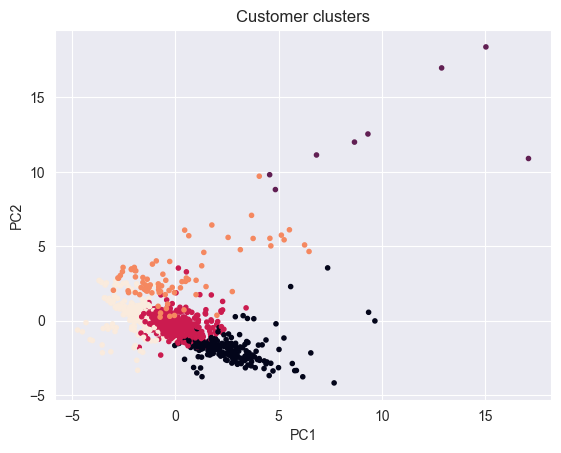

In [36]:
# visualize 2D clusters
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, marker=".")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer clusters")
plt.show()

# Part 2: PCA on unlabelled data

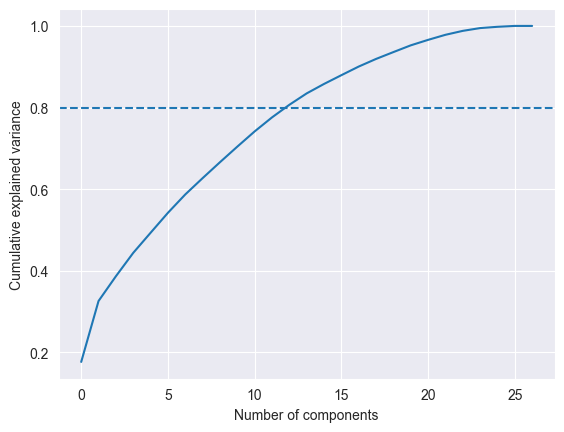

In [37]:
# drop ID column
X = unlabelled_imp.drop(columns=['label'])

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# visualize
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(y=0.8, linestyle='--')
plt.show()

# re-fit pca with opt # components
pca_opt = PCA(n_components=12)
X_pca = pca_opt.fit_transform(X_scaled)

In [38]:
# variation per principal component by feature
loadings_unlabelled = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_opt.n_components_)],
    index=X.columns)

loadings_unlabelled.style.background_gradient(
    cmap="coolwarm",
    subset=[f'PC{i+1}' for i in range(pca_opt.n_components_)])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
cash_value_ratio,-0.033947,0.059792,0.028564,0.101044,-0.132202,0.487381,0.006020,-0.056431,0.491265,0.474444,0.167319,0.206552
emt_velocity_monthly_mean,0.078205,0.074254,0.203159,-0.266493,0.137846,-0.310500,-0.373242,-0.160443,-0.057672,0.199945,0.038522,0.618124
income_transaction_gap_score,0.049193,-0.015159,0.139457,-0.192975,-0.022132,0.003591,0.607725,-0.046382,-0.225870,0.176723,0.341382,0.204672
is_retired,0.035069,-0.047886,0.278589,0.630411,-0.012415,-0.133733,0.048894,-0.012273,-0.035170,0.009612,0.012548,0.015220
is_unemployed,-0.386276,0.195621,-0.019883,-0.091299,0.073991,-0.141960,0.017891,0.015100,0.044817,0.048387,0.051559,-0.018190
occupation_sector_id,-0.260925,0.124646,0.070898,-0.082521,0.099786,-0.221856,0.247982,0.005835,0.056559,0.104062,0.124380,-0.102150
spending_income_ratio,0.314296,-0.081726,-0.107236,0.057129,-0.087294,0.158938,-0.044869,-0.005189,-0.148791,-0.077994,-0.039852,0.071340
rapid_outflow_ratio_24h,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000
mean_debit,0.397694,-0.170978,-0.039290,0.041256,-0.068715,0.160265,-0.063000,-0.008324,-0.061173,-0.056189,-0.048368,0.050337
skew_debit,0.005727,-0.046782,-0.098309,0.062000,0.032854,0.033397,-0.202054,0.581707,-0.272359,-0.085951,0.664638,0.033285


In [18]:
# most important features for each prinicpal component

labelled_features = (loadings['PC1'].abs().sort_values(ascending=False).reset_index())
labelled_features.columns = ['feature', 'PC1_importance']

unlabelled_features = (loadings_unlabelled['PC1'].abs().sort_values(ascending=False).reset_index())
unlabelled_features.columns = ['feature', 'PC1_importance']

merged_importance = pd.merge(labelled_features, unlabelled_features, on='feature', how='left')
merged_importance.columns = ['feature', 'PC1_importance_labelled', 'PC1_importance_unlabelled']

# comparison between labelled vs unlabelled data
merged_importance.style.background_gradient(
    cmap="coolwarm",
    subset=["PC1_importance_labelled", "PC1_importance_unlabelled"])

,feature,PC1_importance_labelled,PC1_importance_unlabelled
0,mean_velocity,0.380725,0.317338
1,late_night_txn_count,0.354034,0.343466
2,std_velocity,0.334722,0.210433
3,unique_merchant_categories,0.320070,0.149229
4,tx_country_n,0.289734,0.131210
5,mean_credit,0.268705,0.263674
6,mean_debit,0.263224,0.397694
7,msb_channels_n,0.241995,0.078342
8,activity_span_days,0.229435,0.107453
9,is_unemployed,0.223132,0.386276


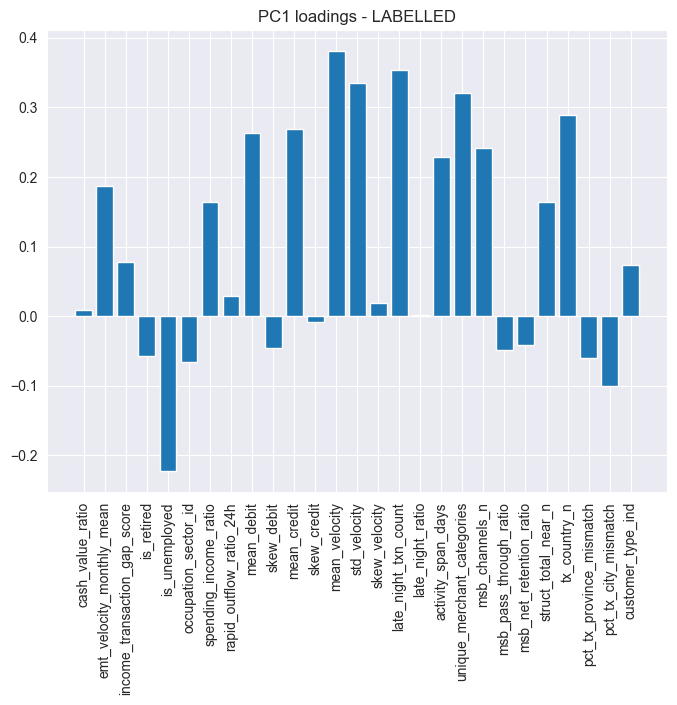

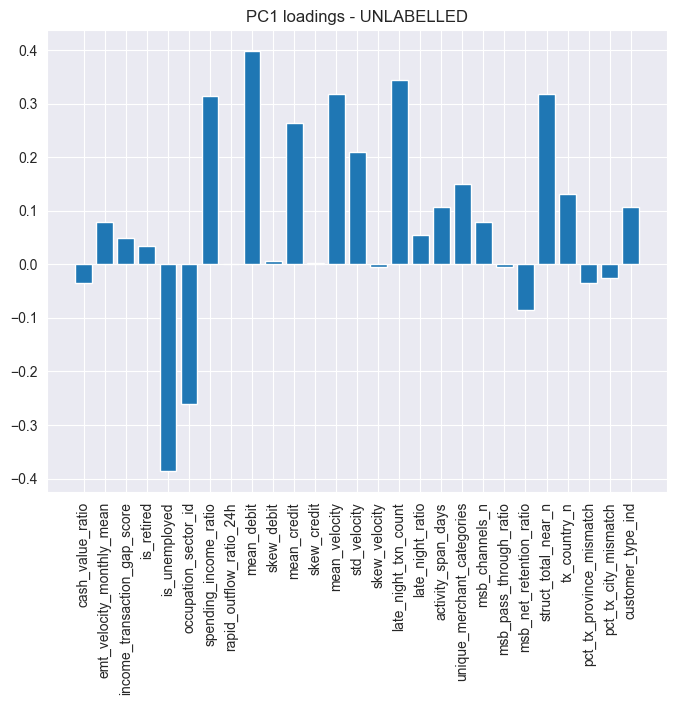

In [19]:
# biplot labelled
plt.figure(figsize=(8,6))
plt.bar(loadings.index, loadings['PC1'])
plt.xticks(rotation=90)
plt.title("PC1 loadings - LABELLED")
plt.show()

# biplot - unlabelled
plt.figure(figsize=(8,6))
plt.bar(loadings_unlabelled.index, loadings_unlabelled['PC1'])
plt.xticks(rotation=90)
plt.title("PC1 loadings - UNLABELLED")
plt.show()

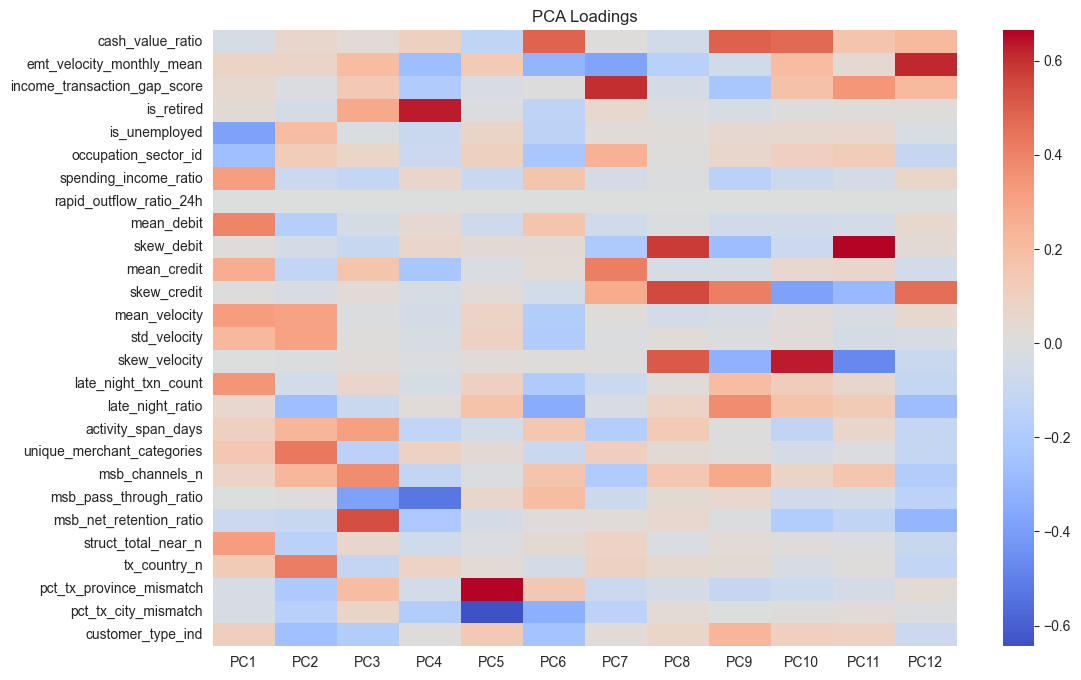

In [20]:
# importance heatmap
plt.figure(figsize=(12,8))
sns.heatmap(loadings_unlabelled, cmap='coolwarm', center=0)
plt.title("PCA Loadings")
plt.show()